## featuretools
Biblioteca de código abierto para realizar ingeniería de funciones automatizada

In [ ]:
! pip install -qU featuretools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 9.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import featuretools as ft

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
data = ft.demo.load_mock_customer()

In [ ]:
df_customers = data["customers"]
df_customers.set_index("customer_id", inplace=True)
df_customers.head()

,zip_code,join_date,birthday
customer_id,,,
1,60091,2011-04-17 10:48:33,1994-07-18
2,13244,2012-04-15 23:31:04,1986-08-18
3,13244,2011-08-13 15:42:34,2003-11-21
4,60091,2011-04-08 20:08:14,2006-08-15
5,60091,2010-07-17 05:27:50,1984-07-28


In [ ]:
df_products = data["products"]
df_products.set_index("product_id", inplace=True)
df_products.head()

,brand
product_id,
1,B
2,B
3,B
4,B
5,A


In [ ]:
df_sessions = data["sessions"]
df_sessions.set_index("session_id", inplace=True)
df_sessions.head()

,customer_id,device,session_start
session_id,,,
1,2,desktop,2014-01-01 00:00:00
2,5,mobile,2014-01-01 00:17:20
3,4,mobile,2014-01-01 00:28:10
4,1,mobile,2014-01-01 00:44:25
5,4,mobile,2014-01-01 01:11:30


In [ ]:
df_transactions = data["transactions"]
df_transactions.set_index("transaction_id", inplace=True)
df_transactions.head()

,session_id,transaction_time,product_id,amount
transaction_id,,,,
2,1,2014-01-01 00:00:00,5,127.64
495,1,2014-01-01 00:01:05,2,109.48
341,1,2014-01-01 00:02:10,3,95.06
308,1,2014-01-01 00:03:15,4,78.92
271,1,2014-01-01 00:04:20,3,31.54


In [ ]:
es = ft.EntitySet()

es = es.add_dataframe(dataframe_name="customers", dataframe=df_customers, index="customer_id")
es = es.add_dataframe(dataframe_name="products", dataframe=df_products, index="product_id")
es = es.add_dataframe(dataframe_name="transactions", dataframe=df_transactions, index="transaction_id")
es = es.add_dataframe(dataframe_name="sessions", dataframe=df_sessions, index="session_id")

es = es.add_relationship("products", "product_id", "transactions", "product_id")
es = es.add_relationship("sessions", "session_id", "transactions", "session_id")
es = es.add_relationship("customers", "customer_id", "sessions", "customer_id")

es

/usr/local/lib/python3.11/dist-packages/featuretools/entityset/entityset.py:1733: UserWarning: index customer_id not found in dataframe, creating new integer column
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.11/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.11/dist-packages/featuretools/entityset/entityset.py:1733: UserWarning: index product_id not found in dataframe, creating new integer column
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could n

Entityset: None
  DataFrames:
    customers [Rows: 5, Columns: 4]
    products [Rows: 5, Columns: 2]
    transactions [Rows: 500, Columns: 5]
    sessions [Rows: 35, Columns: 4]
  Relationships:
    transactions.product_id -> products.product_id
    transactions.session_id -> sessions.session_id
    sessions.customer_id -> customers.customer_id

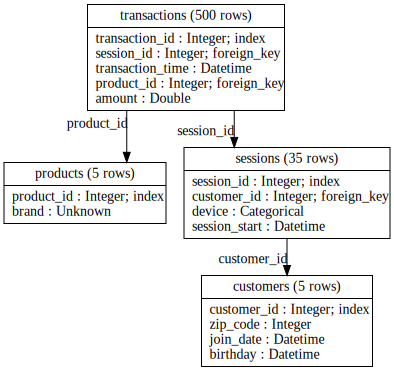

In [ ]:
es.plot()

In [ ]:
#feature_matrix, feature_defs = ft.dfs(entityset=es, target_dataframe_name="products")
feature_matrix, feature_defs = ft.dfs(entityset=es, target_dataframe_name="customers")
#feature_matrix, feature_defs = ft.dfs(entityset=es, target_dataframe_name="transactions")
#feature_matrix, feature_defs = ft.dfs(entityset=es, target_dataframe_name="sessions")

In [ ]:
feature_defs

[<Feature: zip_code>,
 <Feature: COUNT(sessions)>,
 <Feature: MODE(sessions.device)>,
 <Feature: NUM_UNIQUE(sessions.device)>,
 <Feature: COUNT(transactions)>,
 <Feature: MAX(transactions.amount)>,
 <Feature: MEAN(transactions.amount)>,
 <Feature: MIN(transactions.amount)>,
 <Feature: SKEW(transactions.amount)>,
 <Feature: STD(transactions.amount)>,
 <Feature: SUM(transactions.amount)>,
 <Feature: DAY(birthday)>,
 <Feature: DAY(join_date)>,
 <Feature: MONTH(birthday)>,
 <Feature: MONTH(join_date)>,
 <Feature: WEEKDAY(birthday)>,
 <Feature: WEEKDAY(join_date)>,
 <Feature: YEAR(birthday)>,
 <Feature: YEAR(join_date)>,
 <Feature: MAX(sessions.COUNT(transactions))>,
 <Feature: MAX(sessions.MEAN(transactions.amount))>,
 <Feature: MAX(sessions.MIN(transactions.amount))>,
 <Feature: MAX(sessions.SKEW(transactions.amount))>,
 <Feature: MAX(sessions.STD(transactions.amount))>,
 <Feature: MAX(sessions.SUM(transactions.amount))>,
 <Feature: MEAN(sessions.COUNT(transactions))>,
 <Feature: MEAN(ses

In [ ]:
feature_matrix

,zip_code,COUNT(sessions),MODE(sessions.device),NUM_UNIQUE(sessions.device),COUNT(transactions),MAX(transactions.amount),MEAN(transactions.amount),MIN(transactions.amount),SKEW(transactions.amount),STD(transactions.amount),...,STD(sessions.MIN(transactions.amount)),STD(sessions.SKEW(transactions.amount)),STD(sessions.SUM(transactions.amount)),SUM(sessions.MAX(transactions.amount)),SUM(sessions.MEAN(transactions.amount)),SUM(sessions.MIN(transactions.amount)),SUM(sessions.SKEW(transactions.amount)),SUM(sessions.STD(transactions.amount)),MODE(transactions.sessions.device),NUM_UNIQUE(transactions.sessions.device)
customer_id,,,,,,,,,,,,,,,,,,,,,
0,60091,0,NaN,<NA>,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.00,0.000000,0.00,0.000000,0.000000,NaN,<NA>
1,13244,8,mobile,3,119,149.15,75.148655,5.73,0.123116,45.163495,...,5.739770,0.444126,316.388722,1108.98,599.570158,85.21,0.389205,352.566101,mobile,3
2,13244,7,desktop,3,67,146.81,81.233134,5.81,-0.160628,40.371822,...,19.517969,0.483145,418.124271,830.04,486.661571,109.32,0.001909,238.898839,tablet,3
3,60091,6,desktop,3,82,148.86,82.132927,8.73,-0.060535,42.633775,...,17.521535,0.366322,236.944472,811.24,498.781825,129.60,-1.628207,237.283142,desktop,3
4,60091,8,mobile,3,123,149.95,71.882439,6.29,0.165638,42.276191,...,7.111911,0.351386,297.486182,1130.76,582.678756,98.37,1.281989,344.551882,mobile,3


## pycaret

In [ ]:
! pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/

In [ ]:
from pycaret import datasets
df = pycaret.datasets.get_data('insurance')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
from pycaret.regression import RegressionExperiment
exp = pycaret.regression.RegressionExperiment()

# Inicializa el entorno en pycaret y crea el proceso de transformación para preparar los datos para el modelado y la implementación.
reg = exp.setup(data=df, target="charges")

,Description,Value
0,Session id,2114
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 10)"
5,Transformed train set shape,"(936, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


In [ ]:
best = reg.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2529.6695,22204846.6537,4647.6465,0.8445,0.4083,0.2772,0.2420
lightgbm,Light Gradient Boosting Machine,2840.5259,24062667.9920,4830.8861,0.8315,0.4945,0.3337,0.5220
rf,Random Forest Regressor,2703.4096,24556300.8390,4903.4977,0.8278,0.4342,0.3007,0.3830
xgboost,Extreme Gradient Boosting,3019.7529,27757906.8000,5224.1627,0.8049,0.5092,0.3621,0.1410
et,Extra Trees Regressor,2822.3862,28390057.9598,5273.0519,0.8002,0.4666,0.3358,0.3120
ada,AdaBoost Regressor,4374.0564,29187969.2278,5372.6930,0.7933,0.5993,0.6892,0.1420
ridge,Ridge Regression,3956.8456,35607785.9087,5928.5370,0.7508,0.5676,0.4016,0.0710
br,Bayesian Ridge,3949.0486,35606788.8453,5928.1937,0.7508,0.5769,0.4003,0.0730
llar,Lasso Least Angle Regression,3942.2217,35605991.0548,5927.9169,0.7508,0.5997,0.3992,0.0760
lasso,Lasso Regression,3942.2226,35605973.2029,5927.9153,0.7508,0.5997,0.3992,0.0700


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
df = pycaret.datasets.get_data("hepatitis")

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
0,0,30,2,1.0,2,2,2,2,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1
1,0,50,1,1.0,2,1,2,2,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1
2,0,78,1,2.0,2,1,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1
3,0,31,1,NaN,1,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1
4,0,34,1,2.0,2,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1


In [ ]:
from pycaret.classification import ClassificationExperiment

exp = pycaret.classification.ClassificationExperiment()
clf = exp.setup(data=df, target="Class", imputation_type="iterative", categorical_iterative_imputer="rf", numeric_iterative_imputer="rf", iterative_imputation_iters=5)

,Description,Value
0,Session id,1837
1,Target,Class
2,Target type,Binary
3,Original data shape,"(154, 20)"
4,Transformed data shape,"(154, 20)"
5,Transformed train set shape,"(107, 20)"
6,Transformed test set shape,"(47, 20)"
7,Numeric features,19
8,Rows with missing values,48.1%
9,Preprocess,True


In [ ]:
clf.X_train.head()

,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
5,34,1,2.0,2,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.9,95.0,28.0,4.0,75.0,1
74,32,1,1.0,1,1,1,2,2.0,2.0,2.0,2.0,2.0,2.0,1.0,55.0,45.0,4.1,56.0,1
61,32,1,2.0,2,1,1,1,2.0,2.0,2.0,1.0,2.0,1.0,3.5,215.0,54.0,3.4,29.0,1
17,40,1,1.0,2,1,2,2,2.0,1.0,2.0,2.0,2.0,2.0,0.6,62.0,166.0,4.0,63.0,1
65,56,1,1.0,2,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,62.0,33.0,3.0,NaN,1


In [ ]:
best = clf.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,22:31:20
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,SVM - Linear Kernel


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.8018,0.9153,0.7000,0.5583,0.5900,0.4686,0.4943,11.6290
lr,Logistic Regression,0.8700,0.8500,0.5500,0.7500,0.6000,0.5374,0.5680,12.1830
dt,Decision Tree Classifier,0.7764,0.7007,0.5667,0.5167,0.5167,0.3772,0.3925,11.3000
knn,K Neighbors Classifier,0.7000,0.5917,0.0500,0.1000,0.0667,-0.0909,-0.0937,11.3840


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

KeyboardInterrupt: 